In [2]:
from pathlib import Path
import json
import pandas as pd
import numpy as np
def load_direct_data(en, cont, alg, name):
    path = f"./Data/generation_ex/{en}/{cont}/{alg}/{name}"
    json_files = list(Path(path).glob("*.json"))
    print(f"Found {len(json_files)} files!")
    with open(json_files[0], "r", encoding="utf-8") as f:
        data = json.load(f)
    return data

def extract_fitness_values(file_content):
    df = pd.DataFrame(file_content["fitness"]).reset_index(names="seed").melt(
        id_vars="seed", 
        var_name="ng", 
        value_name="population"
    )
    df["ng"] = df["ng"].astype(int)
    df["max_fit"] = df["population"].apply(lambda x: np.max(list(map(lambda y: y[0], x))))
    df["avg_fit"] = df["population"].apply(lambda x: np.mean(list(map(lambda y: y[0], x))))
    df["median_fit"] = df["population"].apply(lambda x: np.median(list(map(lambda y: y[0], x))))
    df["min_fit"] = df["population"].apply(lambda x: np.min(list(map(lambda y: y[0], x))))
    df["std_fit"] = df["population"].apply(lambda x: np.std(list(map(lambda y: y[0], x))))
    return df
def save_final_hyperparameters(en, cont, alg, hyper_paramters):
    
    with open("relevant_finals.json", "r+", encoding="utf-8") as f:
        try:
            data = json.load(f)
        except json.JSONDecodeError:
            data = {}

        f.seek(0)       
        if cont not in data:
            data[cont] = {}
        if en not in data[cont]:
            data[cont][en] = {}
        data[cont][en][alg] = hyper_paramters
        json.dump(data, f)
        f.truncate()

def get_decided():
    with open("relevant_finals.json", "r", encoding="utf-8") as f:
        data = json.load(f)
        df = pd.json_normalize(data)
    return np.unique(list(map(lambda x: ".".join(x.split(".")[0:3]), df.columns)))


In [9]:
en = "cartpole"
cont = "sub_novelty"
alg = "lambda"
file_content = load_direct_data(en, cont, alg, "repaired_try")
df = extract_fitness_values(file_content)

Found 1 files!


In [109]:


df

,seed,ng,population,max_fit,avg_fit,median_fit,min_fit,std_fit
0,104,5,"[[[9.666666666666666], [-0.03209785247842471, ...",50.333333,15.133333,9.666667,9.666667,13.807030
1,102,5,"[[[9.0], [0.0339663897951444, -0.5452829328450...",86.333333,19.455556,9.333333,9.000000,26.232046
2,103,5,"[[[9.666666666666666], [0.0339663897951444, -0...",370.166667,217.066667,235.166667,9.666667,116.135438
3,105,5,"[[[9.333333333333334], [0.0339663897951444, -0...",474.166667,160.600000,37.166667,9.333333,183.783617
4,101,5,"[[[19.0], [0.024682491396864258, -0.5266746621...",130.000000,57.244444,19.000000,9.333333,51.126998
5,104,15,"[[[9.666666666666666], [0.0339663897951444, -0...",56.666667,15.933333,9.666667,9.666667,15.976928
6,102,15,"[[[9.0], [0.0339663897951444, -0.5452829328450...",9.000000,9.000000,9.000000,9.000000,0.000000
7,103,15,"[[[9.0], [0.0339663897951444, -0.5452829328450...",9.833333,9.500000,9.666667,9.000000,0.360041
8,105,15,"[[[145.16666666666666], [0.22178485989570618, ...",262.666667,157.133333,145.166667,9.166667,90.322103
9,101,15,"[[[9.833333333333334], [0.0339663897951444, -0...",29.833333,13.833333,9.833333,9.833333,8.000000


<Axes: xlabel='ng', ylabel='value'>

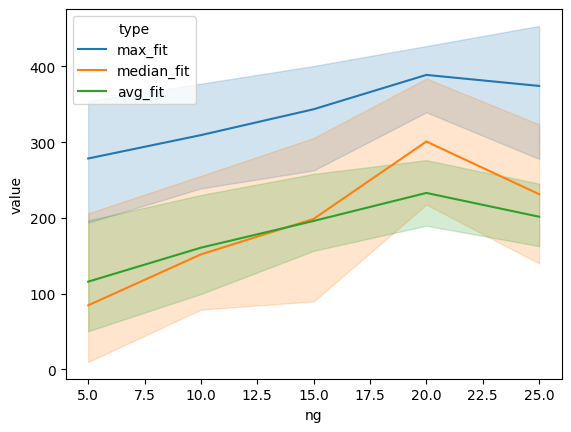

In [10]:
import seaborn as sns
df = df.sort_values("ng")
ploted_df = df[["ng", "seed", "max_fit", "median_fit", "avg_fit"]]
#ploted_df = ploted_df.groupby("ng").mean().reset_index()
if "seed" in ploted_df.columns:
    ploted_df = ploted_df.drop(columns="seed")
ploted_df = ploted_df.melt(
        id_vars="ng", 
        var_name="type", 
        value_name="value"
    )
sns.lineplot(data=ploted_df, x="ng", y="value", hue="type")

In [116]:
file_content["arguments"]

{'l': 15,
 'mr': 0.6000000000000001,
 'cr': 0.8,
 'archiving_period': 3,
 'archive_batch': 3}

In [112]:
get_decided()

array(['elite_archiving.lunarlander.diff',
       'elite_archiving.lunarlander.lambda',
       'fit_archiving.cartpole.diff', 'fit_archiving.cartpole.lambda',
       'fit_archiving.lunarlander.diff',
       'fit_archiving.lunarlander.lambda', 'fitness.cartpole.diff',
       'fitness.cartpole.lambda', 'fitness.lunarlander.diff',
       'fitness.lunarlander.lambda', 'novelty.cartpole.diff',
       'novelty.cartpole.lambda', 'novelty.lunarlander.diff',
       'novelty.lunarlander.lambda', 'novelty_archiving.cartpole.lambda',
       'novelty_archiving.lunarlander.diff',
       'novelty_archiving.lunarlander.lambda',
       'novelty_limit.lunarlander.diff',
       'novelty_limit.lunarlander.lambda'], dtype='<U36')

In [131]:
DECIDED_NG_VALUE = 15   
args = file_content["arguments"]
args["ng"] = DECIDED_NG_VALUE
save_final_hyperparameters(en, cont, alg, args)